Sofia Anaya Palafox

738594

Ingeniería Financiera

## T03 - Greeks


# Parte 1


Parte 1: Observación

1. ¿Cuál opción parece más sensible a cambio en el precio de la acción?
La Opción A, porque tiene un Delta más alto (0.85). Y el delta mide cuánto se mueve la prima de la opción por cada $1 que se mueve la acción..

2. ¿Cuál opción parece más sensible a cambios en volatilidad?
La Opción C, porque tiene el Vega más alto (0.40). Está lejos del precio actual (K=120 vs. $100) y le queda mucho tiempo entonces la volatilidad pues si infiere en lo que pueda llegar o no al mejor precio.

3. ¿Cuál opción parece deteriorarse más rápidamente con el paso del tiempo?
La Opción A, porque tiene el Theta más negativo (-0.10). Le queda muy poco tiempo (1 mes), así que cada día que pasa representa una fracción grande de su vida.

4. ¿Cuál opción parece tener el comportamiento más parecido al de la acción?
La Opción A, porque su Delta (0.85) es el más cercano a 1. Un Delta cercano a 1 significa que se mueve casi "uno a uno" con la acción.

5. ¿Cuál opción parece depender más de que ocurra un evento importante en el futuro?
La Opción C, porque tiene Delta bajo (0.20), está lejos del precio actual y le queda mucho tiempo. Hoy vale poco y solo se vuelve valiosa si pasa algo importante.



# Parte 2


Parte 2: Escenarios de mercado

Escenario A — La acción sube gradualmente durante los próximos meses, sin cambio en volatilidad

Comprarías: Opción B.
Evitarías: Opción A.
Justificación: La Opción A tiene un Theta muy negativo (-0.10) y solo le queda un mes de vida — si el aumento es "gradual durante meses", la opción vencería antes de que el movimiento sea relevante. La Opción B tiene un Delta razonable (0.50) y suficiente tiempo (3 meses) para que la subida gradual se reflejeen el $.

Escenario B — Evento en dos semanas, movimiento brusco pero dirección incierta

Comprarías: Opción C.
Evitarías: Opción A.
Justificación: Como no sabes si el precio subirá o bajará, un Delta alto (A=0.85) es una apuesta direccional arriesgada: si adivinas mal, pierdes fuerte. Lo que te conviene aquí es un Vega alto (C=0.40), que se beneficia de un salto en la volatilidad sin importar hacia dónde se mueva el precio.

Escenario C — La acción se mantendrá muy estable

Comprarías: Opción C.
Evitarías: Opción A.
Justificación: Si nada se mueve, todas las opciones pierden valor por el simple paso del tiempo. La Opción A es la peor, mientras que C tiene el Theta más bajo (-0.01), por lo que se deteriora mucho más lento si el mercado no se mueve.

Escenario D — Crees que va a haber una caída significativa del precio

Evitarías: Opción A.
Justificación: Las tres son opciones call (Delta positivo), así que todas pierden valor si el precio cae — ninguna es realmente "buena" en este escenario. Pero si tuvieras que elegir cuál de las tres te haría perder menos, evitarías A: su Delta alto (0.85) hace que caiga con más fuerza por cada punto que baja la acción. Lo ideal en este escenario sería comprar un put, no una call.

Escenario E — Crees que el mercado está subestimando la incertidumbre futura

Comprarías: Opción C.
Evitarías: Opción A.
Justificación: Esto es una apuesta a que la volatilidad va a subir más de lo que el mercado espera. La Opción C, con su Vega alto (0.40), es mejor por mucho de ese aumento. La Opción A casi ni lo siente (Vega=0.05), así que no sirve de nada literal

# Parte 3


TABLA 1: Aproximacion con GREEKS (mismas griegas fijas del dia inicial)
Mes           Precio   Volat.      dS   dsigma    Valor aprox (Greeks)
Mayo             100      20%       -        -                  6.8887
Junio            102      25%      +2    +0.05                  7.4766
Julio            101      30%      -1    +0.05                  6.2303
Agosto           105      28%      +4    -0.02                  8.1580
Septiembre       103      22%      -2    -0.06                  6.3241
Octubre          110      20%      +7    -0.02                 10.4964

TABLA 2: Valor Black-Scholes simulado (10,000 escenarios Monte Carlo)
Usando precio y volatilidad DE CADA MES, con vencimiento en Octubre
Mes           Precio   Volat.  T restante   Valor Black-Scholes
Mayo             100      20%      0.50 anios                6.8874
Junio            102      25%      0.42 anios                8.7920
Julio            101      30%      0.33 anios                8.1096
Agosto           105    

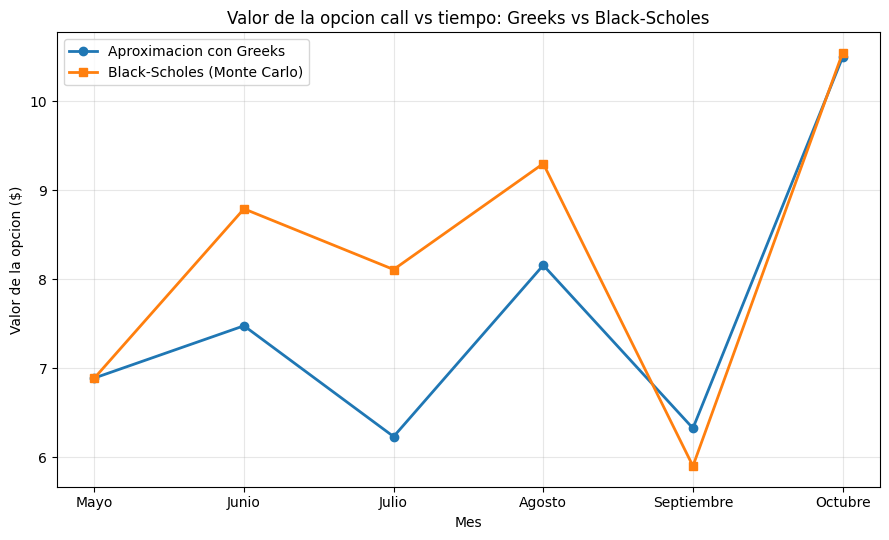

In [9]:
import numpy as np
import matplotlib.pyplot as plt
import os

# Datos
meses = ["Mayo", "Junio", "Julio", "Agosto", "Septiembre", "Octubre"]
precios = [100, 102, 101, 105, 103, 110]
volatilidades = [0.20, 0.25, 0.30, 0.28, 0.22, 0.20]
tiempo_restante = [6/12, 5/12, 4/12, 3/12, 2/12, 1/12]  # a vencimiento (Octubre)

r = 0.05
K = 100
dt = 1/12

# Griegas del dia inicial (Mayo), calculadas con Black-Scholes
V0 = 6.8887
Delta0 = 0.5977
Gamma0 = 0.02736
Vega0 = 0.2814
Theta0_anual = -8.116

np.random.seed(42)


# 1. Funcion de valuacion Monte Carlo (Black-Scholes simulado)
def precio_call_monte_carlo(S, K, T, r, sigma, n_sim=10_000):
    Z = np.random.standard_normal(n_sim)
    ST = S * np.exp((r - 0.5 * sigma**2) * T + sigma * np.sqrt(T) * Z)
    payoff = np.maximum(ST - K, 0)
    return np.exp(-r * T) * np.mean(payoff)


# 2. Tabla 1: Aproximacion con Greeks
print("="*90)
print("TABLA 1: Aproximacion con GREEKS (mismas griegas fijas del dia inicial)")
print("="*90)
print(f"{'Mes':<12}{'Precio':>8}{'Volat.':>9}{'dS':>8}{'dsigma':>9}{'Valor aprox (Greeks)':>24}")

valores_greeks = [V0]
dS_lista = ["-"]
dsigma_lista = ["-"]

for i in range(1, len(meses)):
    dS = precios[i] - precios[i-1]
    dsigma = volatilidades[i] - volatilidades[i-1]

    V_anterior = valores_greeks[-1]
    V_nuevo = (V_anterior
               + Delta0 * dS
               + 0.5 * Gamma0 * dS**2
               + Vega0 * dsigma
               + Theta0_anual * dt)

    valores_greeks.append(V_nuevo)
    dS_lista.append(dS)
    dsigma_lista.append(round(dsigma, 4))

for i, mes in enumerate(meses):
    dS_str = dS_lista[i] if isinstance(dS_lista[i], str) else f"{dS_lista[i]:+d}"
    dsig_str = dsigma_lista[i] if isinstance(dsigma_lista[i], str) else f"{dsigma_lista[i]:+.2f}"
    print(f"{mes:<12}{precios[i]:>8}{volatilidades[i]*100:>8.0f}%{dS_str:>8}{dsig_str:>9}{valores_greeks[i]:>24.4f}")


# 3. Tabla 2: Valor "real" con Black-Scholes (10,000 escenarios)
print("\n" + "="*90)
print("TABLA 2: Valor Black-Scholes simulado (10,000 escenarios Monte Carlo)")
print("Usando precio y volatilidad DE CADA MES, con vencimiento en Octubre")
print("="*90)
print(f"{'Mes':<12}{'Precio':>8}{'Volat.':>9}{'T restante':>12}{'Valor Black-Scholes':>22}")

valores_bs = []
for i, mes in enumerate(meses):
    T = tiempo_restante[i]
    valor_bs = precio_call_monte_carlo(precios[i], K, T, r, volatilidades[i])
    valores_bs.append(valor_bs)
    print(f"{mes:<12}{precios[i]:>8}{volatilidades[i]*100:>8.0f}%{T:>10.2f} anios{valor_bs:>22.4f}")


# 4. Tabla 3: Comparacion y error absoluto
print("\n" + "="*90)
print("TABLA 3: Comparacion Greeks vs Black-Scholes")
print("="*90)
print(f"{'Mes':<12}{'Greeks':>12}{'Black-Scholes':>16}{'Error absoluto':>18}")

errores = [None]  # Mayo no tiene error (es el punto de partida)
print(f"{'Mayo':<12}{'-':>12}{valores_bs[0]:>16.4f}{'-':>18}")
for i in range(1, len(meses)):
    error = abs(valores_greeks[i] - valores_bs[i])
    errores.append(error)
    print(f"{meses[i]:<12}{valores_greeks[i]:>12.4f}{valores_bs[i]:>16.4f}{error:>18.4f}")


# 5. Grafica: Valor de la opcion vs tiempo (Greeks vs Black-Scholes)
plt.figure(figsize=(9, 5.5))
plt.plot(meses, valores_greeks, marker='o', linewidth=2, label='Aproximacion con Greeks')
plt.plot(meses, valores_bs, marker='s', linewidth=2, label='Black-Scholes (Monte Carlo)')
plt.title('Valor de la opcion call vs tiempo: Greeks vs Black-Scholes')
plt.xlabel('Mes')
plt.ylabel('Valor de la opcion ($)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()

# Crear directorio
output_dir = '/mnt/user-data/outputs/'
os.makedirs(output_dir, exist_ok=True)

plt.savefig(os.path.join(output_dir, 'parte3_grafica.png'), dpi=150)
print("\nGrafica guardada en: parte3_grafica.png")


# 6. Analisis
print("\n" + "="*90)
print("ANALISIS")
print("="*90)

# Mes con el error mas grande
idx_max_error = max(range(1, len(meses)), key=lambda i: errores[i])
mes_max_error = meses[idx_max_error]

# Desviacion ACUMULADA de precio y de volatilidad respecto al punto inicial
# (donde se calcularon las greeks: S=100, sigma=20%)
mov_precio_acum = [abs(p - precios[0]) for p in precios]
mov_vol_acum_pct = [abs((v - volatilidades[0]) * 100) for v in volatilidades]  # en puntos de vol

# Correlacion entre el error y cada factor (usando solo Junio-Octubre)
errores_num = errores[1:]
corr_precio = np.corrcoef(mov_precio_acum[1:], errores_num)[0, 1]
corr_vol = np.corrcoef(mov_vol_acum_pct[1:], errores_num)[0, 1]
factor_dominante = "la desviacion de VOLATILIDAD" if abs(corr_vol) > abs(corr_precio) else "la desviacion de PRECIO"

1. ¿Los greeks iniciales describen con precision toda la trayectoria?

   No, el error absoluto no es constante ni pequeño en toda la trayectoria
   la parte en 1.32, sube hasta 1.88 en Julio, y luego baja
   hasta 0.05 en Octubre. Esto pasa porque Delta, Gamma, Vega y Theta se cambian cuando el precio, la volatilidad y el tiempo a vencimiento cambian.

2. ¿En que mes aparecio el error mas grande?
   {mes_max_error}, con un error absoluto de {errores[idx_max_error]:.4f}.
   En ese mes la volatilidad ya se habia desviado {mov_vol_acum_pct[idx_max_error]:.0f}

3. ¿Que factor parece contribuir más al error?
   Medimos la correlación entre el error absoluto y cada factor:
     - Correlacion error vs. desviacion de PRECIO:      {corr_precio:+.3f}
     - Correlacion error vs. desviacion de VOLATILIDAD: {corr_vol:+.3f}
   {factor_dominante} es la que más se correlaciona con el error.
   Aunque el precio termina moviendose más en
   terminos absolutos (llega a 110 en Octubre), el error ahi es el
   MAS PEQUEÑO de toda la tabla, porque para entonces la volatilidad
   ya habia vuelto a su nivel inicial (20%) y el Vega fijo ya no genera nada más. En cambio, el error es mayor cuando la
   volatilidad se aleja mas del 20% original (Junio-Julio), porque
   ahi el Vega y el Theta calculados en Mayo ya no representan bien
   la sensibilidad real de la opcion.

4. ¿Por que los Greeks funcionan mejor para movimientos pequeños?
   Porque son una aproximacion local (derivadas evaluadas en un punto
   especifico: S=100, sigma=20%, T=6/12). Una expansion de Taylor no sirve para cambios grandes esos terminos crecen y
   la aproximacion se aleja del valor real.

5. Si la trayectoria fuera mucho mas volatil, ¿esperarias errores menores?
   No, esperariamos errores MAYORES. Mas volatilidad implica movimientos
   de precio mas grandes y mas frecuentes, alejando el precio de lo que se era original.

6. Conclusion:
   La aproximacion con Greeks es util para cambios pequeños y de corto
   plazo (por ejemplo, cobertura diaria o de unos pocos dias), pero se
   degrada cuando se usa para proyectar varios meses hacia adelante sin
   recalcular las griegas. Por eso no se tienen que calcular las griegas una sola vez y confiar en ellas durante meses: hay que recalcular conforme cambian el precio, la volatilidad y el tiempo.
""")